# QAOA Optimization of the Ising Model

### Overview

This notebook demonstrates the Quantum Approximate Optimization Algorithm (QAOA) implemented within many_body_qsim by solving a classical Ising optimization problem. The Ising Hamiltonian is interpreted as a physical spin model where computational basis states correspond to spin configurations. The QAOA circuit alternates between evolution under a cost Hamiltonian encoding the Ising energy landscape and a mixing Hamiltonian that explores the configuration space.

The optimized QAOA state is compared against the exact ground state obtained through diagonalization, and the resulting probability distribution over spin configurations is visualized.

---

### Imports

Import the quantum circuit simulator, Ising Hamiltonian construction tools, QAOA implementation, and visualization utilities.

In [12]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import minimize

from many_body_qsim.circuits import Quantum_Circuit

from many_body_qsim.hamiltonians import (
    ising_hamiltonian,
    pauli_basis_to_matrix
)

from many_body_qsim.lattices import square_lattice

from many_body_qsim.algorithms import (
    qaoa_energy,
    run_qaoa,
    qaoa_energy_map,
    p_val_probability
)

from many_body_qsim.observables import (
    fidelity,
    expectation_value
)


### QAOA and the Ising Model

QAOA is designed to solve optimization problems by mapping them onto a cost Hamiltonian whose ground state represents the optimal solution. Many combinatorial optimization problems (e.g. Max-Cut, graph partitioning, scheduling, and routing) can be rewritten as an Ising Hamiltonian,

$$
H_C=-\sum_{\langle i,j\rangle}J_{ij}Z_iZ_j-\sum_i h_iZ_i,
$$

where the eigenvalue of each computational basis state equals the objective value of one candidate solution. Solving the optimization problem can therefore be mapped to finding the optimal spin state configurations in a physical system based on the Ising model.

---

### Physical Interpretation

Each qubit represents one classical spin. Because computational basis states are eigenstates of the Pauli-$Z$ operator, there is a direct correspondence between bitstrings and spin configurations:

$$
|0\rangle \longleftrightarrow s_i=+1
\qquad
|1\rangle \longleftrightarrow s_i=-1
$$

with the computational basis states satisfying

$$
Z|0\rangle=+|0\rangle,
\qquad
Z|1\rangle=-|1\rangle,
$$

meaning that the binary value stored by each qubit directly represents a physical spin:

- Bit 0 $\rightarrow$ spin up ($+1$)
- Bit 1 $\rightarrow$ spin down ($-1$)

Every computational basis state represents one possible spin configuration of the lattice and one candidate solution to the optimization problem.

For example,

$$
001101
$$

corresponds to the state with spin configuration

$$
\uparrow\uparrow\downarrow\downarrow\uparrow\downarrow.
$$

where qubit index corresponds to site index on the lattice. Consequently, every measured bitstring simultaneously represents

- a computational basis state,
- a classical spin configuration,
- and one candidate solution of the optimization problem.

The coupling constants $J_{ij}$ determine interactions between neighboring spins:

- $J>0$ — ferromagnetic (neighboring spins prefer to align)
- $J<0$ — antiferromagnetic (neighboring spins prefer opposite orientations)

The local fields $h_i$ bias individual spins toward one orientation and can encode additional problem constraints. For the purposes of this example, J and h are constant. This can be interpreted here as identical interaction strengths between nearest neighbor sites, and the direction and magnitude of an external uniform magnetic field in $\hat{z}$ ($h>0$ up, $h<0$ down).


### Construct the Cost Hamiltonian

In [13]:
Nx = 2
Ny = 2
N = Nx * Ny

bonds = square_lattice(Nx, Ny)

cost_H = ising_hamiltonian(bonds, J = 1, h = 10, axis='Z')
cost_H

{'ZZII': -1,
 'ZIZI': -1,
 'IZIZ': -1,
 'IIZZ': -1,
 'ZIII': -10,
 'IZII': -10,
 'IIZI': -10,
 'IIIZ': -10}

### Exact Ground State

In [14]:
cost_H_matrix = pauli_basis_to_matrix(cost_H)

eigenvalues, eigenvectors = np.linalg.eig(cost_H_matrix)


exact_energy = eigenvalues[0]

exact_state = eigenvectors[:,0]


print(f'Exact ground energy: {exact_energy}')

Exact ground energy: (-44+0j)


### QAOA Circuit

QAOA begins in the equal superposition

$$
|+\rangle^{\otimes N}
=
\frac{1}{\sqrt{2^N}}
\sum_z |z\rangle,
$$

allowing every possible solution to be explored.

Each QAOA layer alternates between two unitary evolutions:

#### Cost Evolution

$$
U_C(\gamma)=e^{-i\gamma H_C}.
$$

This operation applies an energy-dependent phase to every computational basis state. States with different Ising energies accumulate different phases while their probabilities remain unchanged.

#### Mixer Evolution

$$
U_B(\beta)=e^{-i\beta H_B},
\qquad
H_B=\sum_i X_i.
$$

The mixer rotates qubits about the $X$-axis, transferring probability amplitude between different bitstrings. The phases introduced by the cost Hamiltonian interfere during this evolution, increasing the probability of measuring low-energy configurations while suppressing higher-energy ones.

One QAOA operation is

$$
U_B(\beta)U_C(\gamma)|+\rangle^{\otimes N},
$$

and a depth-$p$ circuit repeats this process using independent parameters $\{\beta_k,\gamma_k\}$.

$$
|\psi(\beta,\gamma)\rangle = \prod\limits_{k=1}^{p}
U_B(\beta_k)U_C(\gamma_k)|+\rangle^{\otimes N},
$$

### Run QAOA

In [15]:
p = 2

qaoa_results = run_qaoa(
    cost_H,
    p=p,
    optimizer='COBYLA'
)


optimal_parameters = qaoa_results['parameters']
qaoa_energy_value = qaoa_results['cost']

### Energy Comparison

In [16]:
print(f'Exact ground energy: {exact_energy}')
print(f'QAOA energy:         {qaoa_energy_value}')
print(f'Optimal parameters:  {optimal_parameters}')

Exact ground energy: (-44+0j)
QAOA energy:         -43.16395143647005
Optimal parameters:  [0.22932119 2.84807863 1.28955285 5.73158665]


The QAOA energy approaches the exact ground-state energy as the circuit depth p increases. At finite depth, QAOA generally does not reproduce the exact state, but instead produces a state whose measurement distribution favors low-energy configurations.

---

### Optimized QAOA State Circuit

In [17]:
qaoa_state = qaoa_results['state']
qaoa_state.draw()

q0: ──────[H]─────────●─────────────────────●──────────●─────────────────────●──────────────────────────────────────
                      │                     │          │                     │                                      
q1: ──────[H]─────────X─────────[RZ]────────X──────────│─────────────────────│──────────●─────────────────────●─────
                               (-0.5)                  │                     │          │                     │     
q2: ──────[H]──────────────────────────────────────────X─────────[RZ]────────X──────────│─────────────────────│─────
                                                                (-0.5)                  │                     │     
q3: ──────[H]───────────────────────────────────────────────────────────────────────────X─────────[RZ]────────X─────
                                                                                                 (-0.5)             

q0: ────────────────────────────[RZ]───────[H]────────[RZ]─────

The ideal QAOA circuit at a p-depth $p=2$ for this predicted parameter set.

### State Probability Distribution

Unlike VQE, where the primary objective is preparing a ground-state approximation, QAOA produces a probability distribution over possible solutions. Each bitstring corresponds to a classical spin configuration. The highest-probability states should correspond to the lowest-energy Ising configurations.

In [18]:
p_depth_probabilities = p_val_probability(cost_H, 4)

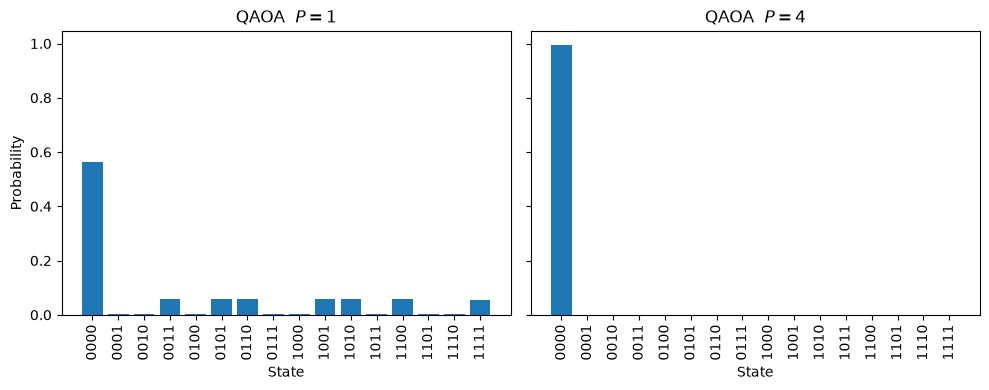

In [19]:
labels = [
    format(i, f'0{qaoa_state.numqubits}b')
    for i in range(2**qaoa_state.numqubits)
]

fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# Top histogram
ax[0].bar(labels, p_depth_probabilities[0])
ax[0].set_ylabel('Probability')
ax[0].set_title(r'QAOA  $P=1$')
ax[0].set_xlabel('State')
ax[0].tick_params(axis='x', rotation=90)

# Bottom histogram
ax[1].bar(labels, p_depth_probabilities[3])
#ax[1].set_ylabel('Probability')
ax[1].set_xlabel('State')
ax[1].set_title(r'QAOA  $P=4$')

ax[1].tick_params(axis='x', rotation=90)

plt.tight_layout()

As expected, a higher p-depth results in increased probability for the circuit to return the 
optimal state. Here, QAOA predicts $|0000\rangle$ for a four-site lattice with a positive 
J and h values. 

This fits expectation, because $J>0$ values result in ferromagnetism (i.e. all
spins poting in the same direction), and the positive magnetic field in the up direction $h>0$ ensures 
that the lowest energy state is when all spins are aliged with each other in the direction of the magnetic field.
In this example, QAOA successfully identifies the optimal ground-state configuration for a physical many-body system.

A useful measure of QAOA performance is the probability of sampling the true ground state.

In [20]:
ground_probability = (
    np.abs(
        np.vdot(
            exact_state,
            qaoa_state.state
        )
    )**2
)


print(
    f'Ground state probability: {ground_probability}'
)

Ground state probability: 0.9861434740213132


### Gamma-Beta Parameter Landscape

For a shallow QAOA circuit for $p=1$, the optimization landscape can be visualized directly by scanning over the variational parameters. This shows how the choice of γ and β controls the quality of the prepared state.

In [21]:
gammas = np.linspace(0, np.pi, 100)
betas = np.linspace(0, np.pi, 100)
E_map = qaoa_energy_map(
    cost_H,
    gammas = gammas,
    betas = betas
)

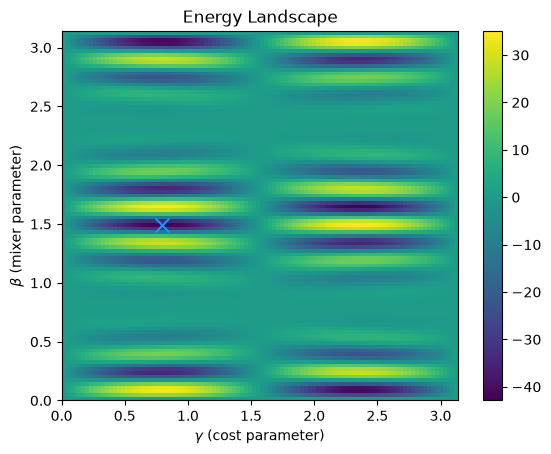

In [22]:
plt.imshow(
    E_map, 
    origin='lower',
    aspect='auto',
    extent=[
        gammas[0],
        gammas[-1],
        betas[0],
        betas[-1]
    ],
    cmap='viridis'
)
plt.xlabel(r'$\gamma$ (cost parameter)')
plt.ylabel(r'$\beta$ (mixer parameter)')
plt.title('Energy Landscape')
plt.colorbar()

min_index = np.unravel_index(np.argmin(E_map), E_map.shape)

best_beta = betas[min_index[0]]
best_gamma = gammas[min_index[1]]
plt.scatter(
    best_gamma,
    best_beta,
    color = 'dodgerblue',
    marker='x',
    s=100
)

The energy landscape demonstrates which cost and mixer parameter values result in which predicted energies, 
with the predicted optimal lowest energy of this cost Hamiltonian for $p=1$ marked by the blue cross.

### Discussion

The QAOA implementation successfully identifies low-energy spin configurations of the Ising model. Unlike VQE, which attempts to approximate a single quantum ground state through variational minimization of the energy expectation value, QAOA produces a probability distribution over candidate solutions.

The Ising Hamiltonian provides a direct connection between quantum optimization and condensed matter physics: computational basis states represent physical spin configurations, and minimizing the cost function corresponds to finding the ground-state spin arrangement.

For the ferromagnetic case (J>0,h>0), QAOA concentrates probability near the ground state consisting of all spins aligned along the magnetic field. Increasing the circuit depth p increases the expressibility of the ansatz and generally improves the probability of sampling optimal configurations, at the cost of additional circuit complexity.